## Exploration of Titanic Data and Prediction of Survival

This notebook will aim to:
1. Assess and explore relationships between the features in the data
2. Create new features from the available ones both in the train and test data
3. Impute missing values with justifiable ones
4. Explore various algorithms(Classifiers)
5. Select the best algorithm to help predict an unseen data(test)
6. Fine tune hyperparameters to create an optimum model
7. Predict survival from the test data

Progressively, libraries will be imported as required

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df_train = pd.read_csv('./train.csv')
df_test = pd.read_csv('./test.csv')

In [3]:
print(df_train.head(2))
print("*"*20)
print(df_test.head(2))

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   

   Parch     Ticket     Fare Cabin Embarked  
0      0  A/5 21171   7.2500   NaN        S  
1      0   PC 17599  71.2833   C85        C  
********************
   PassengerId  Pclass                              Name     Sex   Age  SibSp  \
0          892       3                  Kelly, Mr. James    male  34.5      0   
1          893       3  Wilkes, Mrs. James (Ellen Needs)  female  47.0      1   

   Parch  Ticket    Fare Cabin Embarked  
0      0  330911  7.8292   NaN        Q  
1      0  363272  7.0000   NaN        S  


##### **Feature Observations**

Here we will look at the potential of every feature in feature engineering.

**1. _PassengerID_** - does not have any indication to create a new feature from it.

**2. _Survived_** - is a class feature to be predicted with regard to each passengerin the test data thus no feature can be derived from it.

**3. _Pclass_** - is class feature detailing the ticket classification if 1st, 2nd, or 3rd and no feature can be got from it.

**4. _Name_** - is the string of words unique to each passenger but has potential to create **Title** and **Surname** features.

**4. _Sex_** - is categorical feature detailing passenger orientation if male or female and no feature can be created from it.

**5. _Age_** - is an ordinal unique feature showing amount of years lived and can create an **AgeGroup** categorical feature.

**6. _SibSp_** - is a feature showing the relationship of either Sibling or Spouse and create a **FamilySize** feature together with the **Parch** feature.

**7. _Parch_** - is a feature showing the relationship of either Parent or Child and can create a **FamilySize** feature together with the **SibSp** feature.

**8. _Ticket_** - is a feature detailing the unique ticket number of each passenger and can be explored to create **T_Prefix** feature.

**9. _Fare_** - is a feature showing the amount paid by each passenger and can help create a **FareGroup** feature.

**10. _Cabin_** - is a feature detailing in which cabin the passenger was in or assigned and could create a categorical **CabinClass** feature.

**11. _Embarked_** - is a feature detailing the port of entry by passenger and has no potent to create another feature.

#### **Initial Exploration**

In [4]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## Missing data check

In [5]:
# identify datatypes of the 11 columns, add the stats to the datadict
datadict = pd.DataFrame(df_train.dtypes)

# identify missing values of the 11 columns,add the stats to the datadict
datadict['MissingVal'] = df_train.isnull().sum()
datadict['MissingVal %'] = round((df_train.isnull().sum() / df_train.shape[0]) * 100, 2)

# Identify number of unique values, For object nunique will the number of levels
# Add the stats the data dict
datadict['NUnique']=df_train.nunique()

# Identify the count for each variable, add the stats to datadict
datadict['Count']=df_train.count()

# rename the 0 column
datadict = datadict.rename(columns={0:'DataType'})

datadict

,DataType,MissingVal,MissingVal %,NUnique,Count
PassengerId,int64,0,0.00,891,891
Survived,int64,0,0.00,2,891
Pclass,int64,0,0.00,3,891
Name,object,0,0.00,891,891
Sex,object,0,0.00,2,891
Age,float64,177,19.87,88,714
SibSp,int64,0,0.00,7,891
Parch,int64,0,0.00,7,891
Ticket,object,0,0.00,681,891
Fare,float64,0,0.00,248,891


**Observations**

1. Age has about 20% missing values which can be imputed with either mean, mode or median
2. Cabin has about 77% missing values and any imputation will give a distribution not representative of actual or close enough.
3. Emabarked has about 0.22% missing values giving an indication of an easy imputation of the missing values
4. All the other features do not have missing values.

## Variable description ##

In [6]:
df_train.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,B96 B98,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


**Observation**

1. Minimum fare is 0 and also seems not normal

#### **Imputation of Age, Embarked, Sex and Embarked Features  --- training**

In [60]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder


# data used in imputing
data_impute = df_train[['Pclass', 'Sex','Age', 'SibSp','Parch', 'Fare', 'Embarked']]

***only 2 observations in Embarked missing, replace with model***

In [61]:
## check Embarked missing ##
print ("*"*50+"missing Embarked"+"*"*50)
print (data_impute[data_impute['Embarked'].isnull()])

# Find the mode (most frequent value)
mode_value = data_impute['Embarked'].mode()[0]
print(f"Mode of Embarked: {mode_value}")

# Replace missing values with mode
data_impute['Embarked'] = data_impute['Embarked'].fillna(mode_value)

print ("#### after missing Embarked replaced by mode")
print(data_impute.loc[[62,830]])

## dummy encoding sex and embark for imputation

# Sex and Embarked encoding

Impute_dummy = pd.get_dummies(data_impute[['Sex', 'Embarked']], drop_first=True)
Impute = pd.concat([data_impute, Impute_dummy], axis=1)
Impute.drop(['Sex', 'Embarked'], axis=1, inplace=True)

print ("*"*50)
print(Impute.head(2))


**************************************************missing Embarked**************************************************
     Pclass     Sex   Age  SibSp  Parch  Fare Embarked
61        1  female  38.0      0      0  80.0      NaN
829       1  female  62.0      0      0  80.0      NaN
Mode of Embarked: S
#### after missing Embarked replaced by mode
     Pclass     Sex   Age  SibSp  Parch     Fare Embarked
62        1    male  45.0      1      0  83.4750        S
830       3  female  15.0      1      0  14.4542        C
**************************************************
   Pclass   Age  SibSp  Parch     Fare  Sex_male  Embarked_Q  Embarked_S
0       3  22.0      1      0   7.2500      True       False        True
1       1  38.0      1      0  71.2833     False       False       False


/var/folders/3d/c20qd2t57zvbpp10zzxyxz1r0000gn/T/ipykernel_88700/1194314966.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_impute['Embarked'] = data_impute['Embarked'].fillna(mode_value)


**Age missing imputation**

In [65]:

####################################
####################################
# Age impute missing: 1. scalar 2. KNN impute 3. scalar back

print("*"*50+"impute Age"+"*"*50)

# Pre-KNN, scalar the variables since KNN is distance based calculation
scaler = MinMaxScaler()
X_train_scalar = scaler.fit_transform(Impute)
data_train_scalar = pd.DataFrame(data=X_train_scalar, columns=Impute.columns)

print("*"*50)
print ("---after scalar, missing records----")
print(data_train_scalar.isnull().sum())
print ("---after scalar, not missing records----")
print(data_train_scalar.notnull().sum())

print("*"*50)

# Imputing Missing Values
knn_imputer = KNNImputer(weights='distance', copy=True)
X_train_KNN = knn_imputer.fit_transform(data_train_scalar)
data_train_KNN_scalar = pd.DataFrame(X_train_KNN, columns=Impute.columns)
print ("---after KNN, missing records----")
print(data_train_KNN_scalar.isnull().sum())
print ("---after KNN, not missing records----")
print(data_train_KNN_scalar.notnull().sum())

print("*"*50)

## inverse scalar data back: datainv
Xinv_train = scaler.inverse_transform(data_train_KNN_scalar)
data_train_KNN = pd.DataFrame(data=Xinv_train, columns=Impute.columns)
print ("---after scalar back, missing records----")
print(data_train_KNN.isnull().sum())
print ("---after scalar back, not missing records----")
print(data_train_KNN.notnull().sum())

print("*"*50)
print ("---sampled imputed Age----")
data_train_age = data_train_KNN['Age']
print(data_train_age.head(2))

**************************************************impute Age**************************************************
**************************************************
---after scalar, missing records----
Pclass          0
Age           177
SibSp           0
Parch           0
Fare            0
Sex_male        0
Embarked_Q      0
Embarked_S      0
dtype: int64
---after scalar, not missing records----
Pclass        891
Age           714
SibSp         891
Parch         891
Fare          891
Sex_male      891
Embarked_Q    891
Embarked_S    891
dtype: int64
**************************************************
---after KNN, missing records----
Pclass        0
Age           0
SibSp         0
Parch         0
Fare          0
Sex_male      0
Embarked_Q    0
Embarked_S    0
dtype: int64
---after KNN, not missing records----
Pclass        891
Age           891
SibSp         891
Parch         891
Fare          891
Sex_male      891
Embarked_Q    891
Embarked_S    891
dtype: int64
*************************

#### **Imputation of Age, Fare, Sex and Embarked Features  --- testing**

In [10]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder


## check Embarked missing ##
print ("*"*50+"missing Embarked"+"*"*50)
print (df_test[df_test['Embarked'].isnull()])
print ("************no missing Embarked*******")

**************************************************missing Embarked**************************************************
Empty DataFrame
Columns: [PassengerId, Pclass, Name, Sex, Age, SibSp, Parch, Ticket, Fare, Cabin, Embarked]
Index: []
************no missing Embarked*******


### imput age ###
###############
#################
#################
X_test = df_test[['Age']]
# Scale test data using scaler fitted on training
X_test_scalar = scaler.transform(X_test)
data_test_scalar = pd.DataFrame(data=X_test_scalar, columns=X_test.columns)


# Impute test data using imputer fitted on training
X_test_KNN = knn_imputer.transform(data_test_scalar)
data_test_KNN_scalar = pd.DataFrame(X_test_KNN, columns=X_test.columns)

## inverse scalar data back: datainv
Xinv_test = scaler.inverse_transform(data_test_KNN_scalar)
data_test_KNN = pd.DataFrame(data=Xinv_test, columns=X_test.columns)
data_test_age = data_test_KNN 


print("After reset_index(drop=True):")
# Now concatenate
data_train = pd.concat([data_test_unchanged, 
                              data_test_dumm, 
                              data_test_age], axis=1)
print (data_test.isnull().sum())
print (data_test.shape)

#### **Exploration the Relationship of Features to Survival**

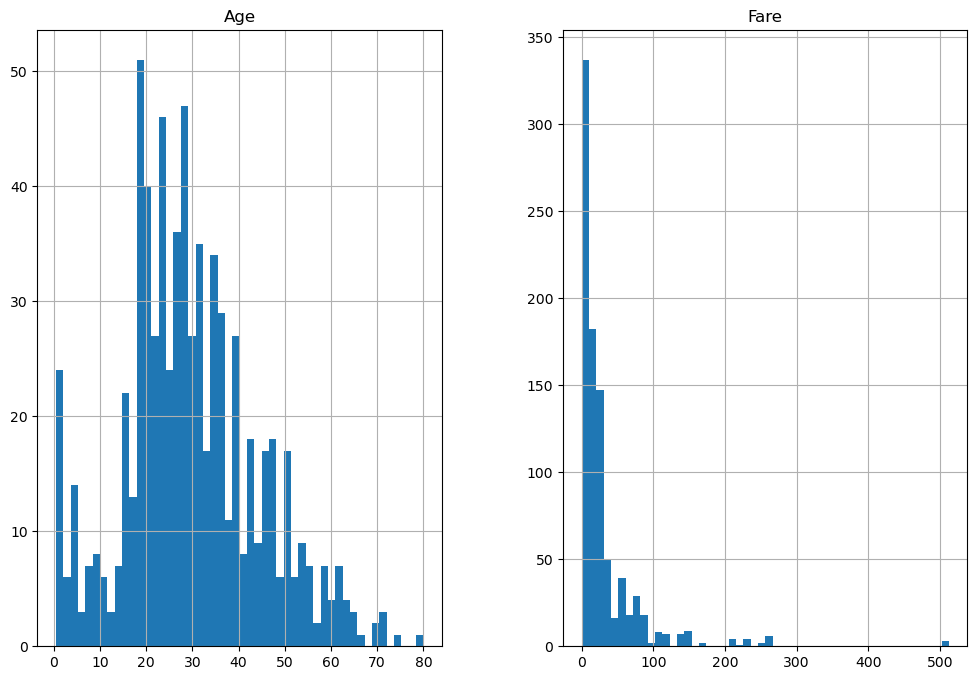

In [11]:
# plot continous variables #

df_train[['Age', 'Fare']].hist(bins=50, figsize=(12, 8))
plt.show()

1. sex

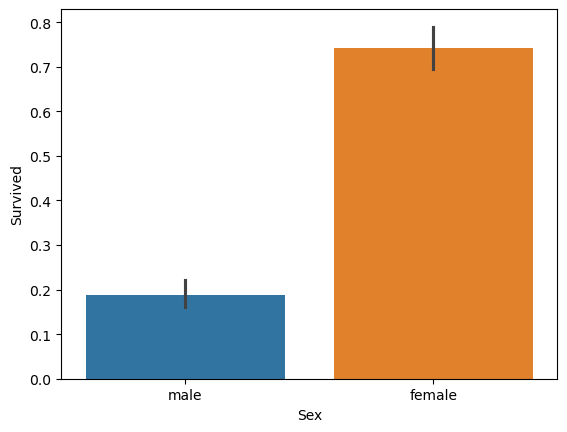

In [12]:
sns.barplot(data=df_train, x='Sex', y='Survived', hue='Sex')
plt.show()

**Observation**

Being a female, there is a likelihood to survive.

2. **Pclass**

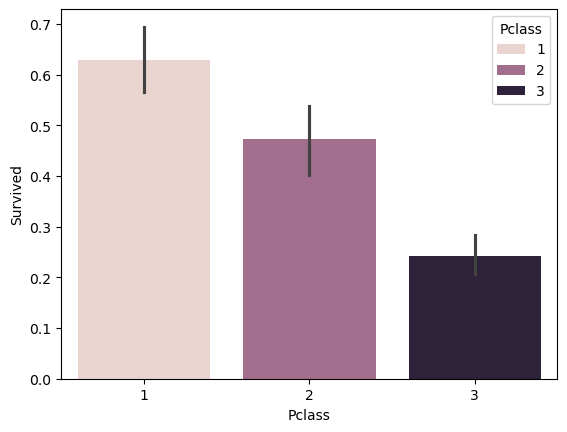

In [13]:
sns.barplot(data=df_train, x= 'Pclass', y='Survived', hue='Pclass')
plt.show()

**Observation**

Passenger class 1 and 2 have a higher likelihood to survive.

3. **Age**

We will create a new class feature - **AgeGroup** which will assist in classification of age and give the general relationship with the **Survival** feature.
Classification will be as follows:

0-5 -> Baby

6-15 -> Child

16-35 -> Youth

36-55 -> Adult

55-80 -> Senior

  Age 25th, 50th, 75th: [nan nan nan nan nan nan]


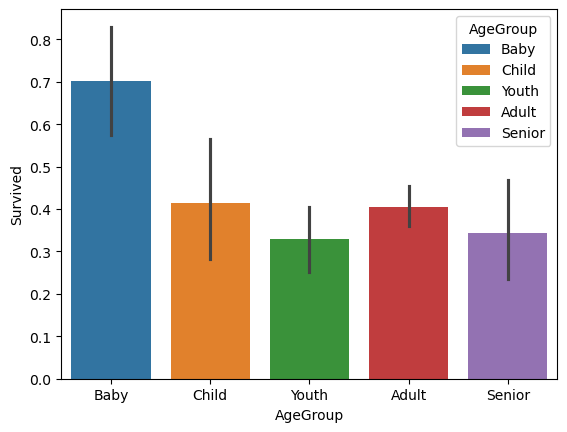

In [14]:
import numpy as np

print(f"  Age 25th, 50th, 75th: {np.percentile(df_train['Age'], [5, 10,25, 50,75,90])}")


bins = [0, 6, 16 , 22, 50, np.inf]
labels = ['Baby', 'Child', 'Youth', 'Adult', 'Senior']

df_train_copy =df_train.copy()
df_train_copy['AgeGroup'] = pd.cut(df_train_copy['Age'], bins = bins, labels = labels)

sns.barplot(data=df_train_copy, x='AgeGroup', y='Survived', hue='AgeGroup')
plt.show()


**Observation**

1. Babies have a high likelihood to survive
2. Childrend and Adults have a similar likelihood to survive almost shared with youths
3. Seniors have the lowest survival rate




4. **SibSp**

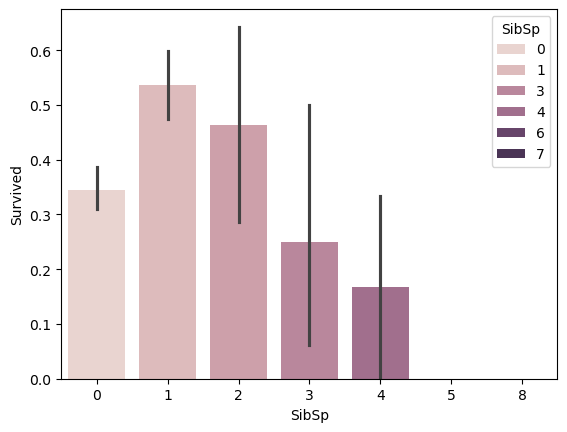

In [15]:
sns.barplot(data=df_train, x='SibSp', y='Survived', hue='SibSp')
plt.show()

**Observations**

There is a high likelihood to survive for a passenger who is alone or with only one extra person.

5. **Parch**

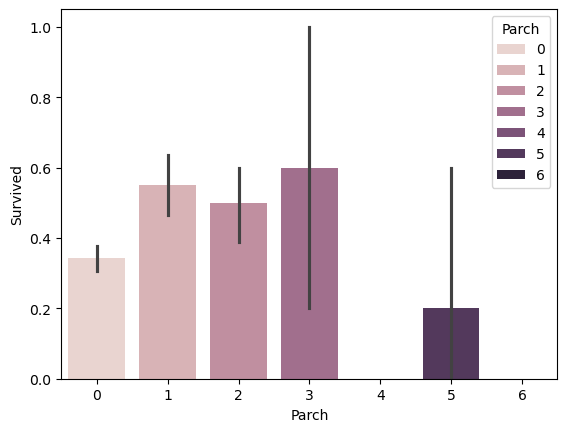

In [16]:
sns.barplot(data=df_train, x='Parch', y='Survived', hue='Parch')
plt.show()

**Observation**

Passengers with parent child relationship were more likely to survive.

6. **Ticket**

In [17]:
891 - int(df_train['Ticket'].unique().shape[0])

210

Only 210 tickets are shared among the passengers giving the impression that less could be got from the Ticket feature.

7. **Fare**

There are fares which are zero which is not factual. This notebook will impute them using Pclass means.

In [18]:
df_train[['Fare', 'Pclass']][df_train['Fare'] == 0]

,Fare,Pclass
179,0.0,3
263,0.0,1
271,0.0,3
277,0.0,2
302,0.0,3
413,0.0,2
466,0.0,2
481,0.0,2
597,0.0,3
633,0.0,1


In [19]:
pclass_mean1 = round(df_train['Fare'][df_train['Pclass'] == 1].mean(), 4)
pclass_mean2 = round(df_train['Fare'][df_train['Pclass'] == 2].mean(), 4)
pclass_mean3 = round(df_train['Fare'][df_train['Pclass'] == 3].mean(), 4)
print(f'Mean 1: {pclass_mean1}, Mean 2: {pclass_mean2}, Mean : {pclass_mean3}')

Mean 1: 84.1547, Mean 2: 20.6622, Mean : 13.6756


In [20]:
df_train_copy['Fare'][(df_train_copy['Pclass'] == 1) & (df_train_copy['Fare'] == 0)] = pclass_mean1
df_train_copy['Fare'][(df_train_copy['Pclass'] == 2) & (df_train_copy['Fare'] == 0)] = pclass_mean2
df_train_copy['Fare'][(df_train_copy['Pclass'] == 3) & (df_train_copy['Fare'] == 0)] = pclass_mean3

/var/folders/3d/c20qd2t57zvbpp10zzxyxz1r0000gn/T/ipykernel_88700/2131452734.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_train_copy['Fare'][(df_train_copy['Pclass'] == 1) & (df_train_copy['Fare'] == 0)] = pclass_mean1
/var/folders/

  Age 25th, 50th, 75th: [ 7.2292  7.7375  7.925  14.5    31.275  78.85  ]


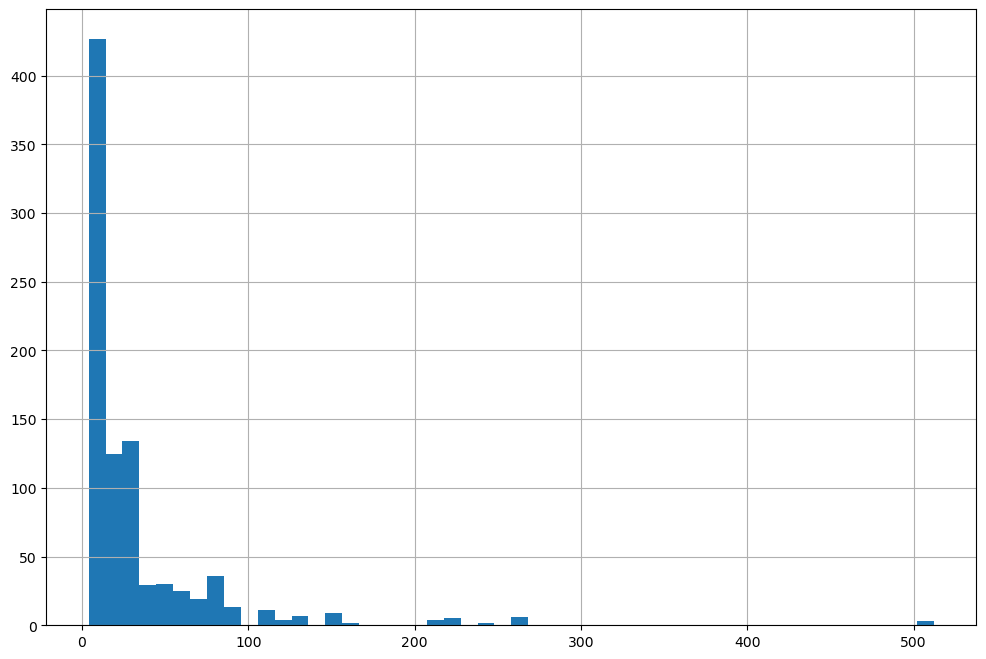

In [21]:
print(f"  Age 25th, 50th, 75th: {np.percentile(df_train_copy['Fare'], [5, 10,25, 50,75,90])}")

df_train_copy['Fare'].hist(bins=50, figsize=(12, 8))
plt.show()

Due to the disparity of the fare this notebook will create **FareGroup** feature as classified as:

0-40 -> Low(1)

41-100 -> Mid(2)

101-200 -> High(3)

201-500+ -> V.High(4)

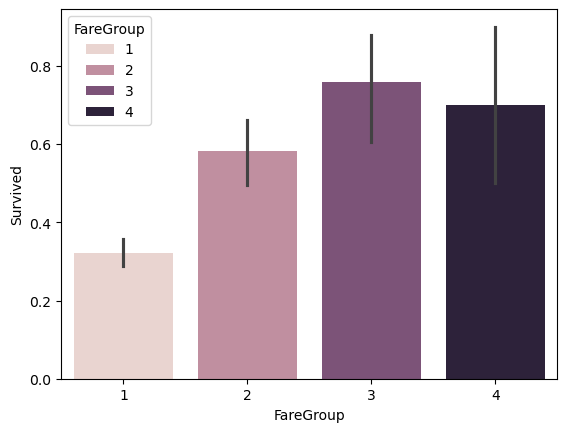

In [22]:
df_train_copy['FareGroup'] = pd.cut(df_train_copy['Fare'], bins = [0, 41, 101, 201, np.inf], labels=[1, 2, 3, 4]).astype(int)

sns.barplot(data=df_train_copy, x='FareGroup', y='Survived', hue='FareGroup')
plt.show()

8. **Embarked**

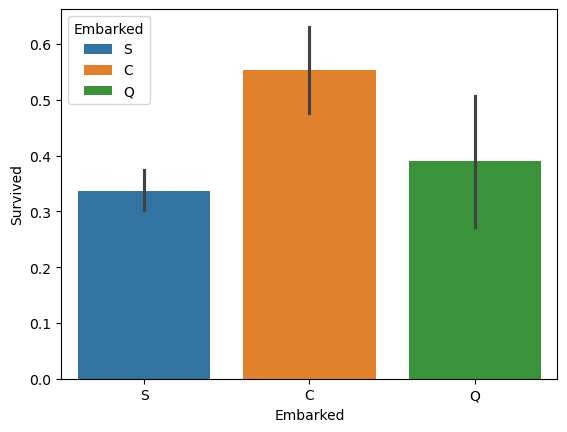

In [23]:
sns.barplot(data=df_train, x='Embarked', y='Survived', hue='Embarked')
plt.show()

**Observations**

Passengers who embarked at Cherbourg had a high likelihood of survival with those at Southampton having the lowest of the three embarkment points.

9. **Name**

In [24]:
# Funtion to take the dataframe and feature, pick the title and return a list of the titles
def titling(X, attrib):
    titles = []
    for i in range(len(X)):
        titles.append(str(df_train[attrib][i]).split('.')[0].split(',')[1].strip(' '))

    return titles

df_train_copy['Title'] = titling(df_train_copy, 'Name')
print(df_train_copy['Title'].unique())

print(df_train_copy.head(5))


['Mr' 'Mrs' 'Miss' 'Master' 'Don' 'Rev' 'Dr' 'Mme' 'Ms' 'Major' 'Lady'
 'Sir' 'Mlle' 'Col' 'Capt' 'the Countess' 'Jonkheer']
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked AgeGroup  FareGroup Title  
0      0         A/5 21171   7.2500   NaN        S    Youth          1    Mr  
1      0          PC 17599  71.2833  

/var/folders/3d/c20qd2t57zvbpp10zzxyxz1r0000gn/T/ipykernel_88700/2458066872.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(labels=df_train_copy['Title'].unique(), rotation=45)


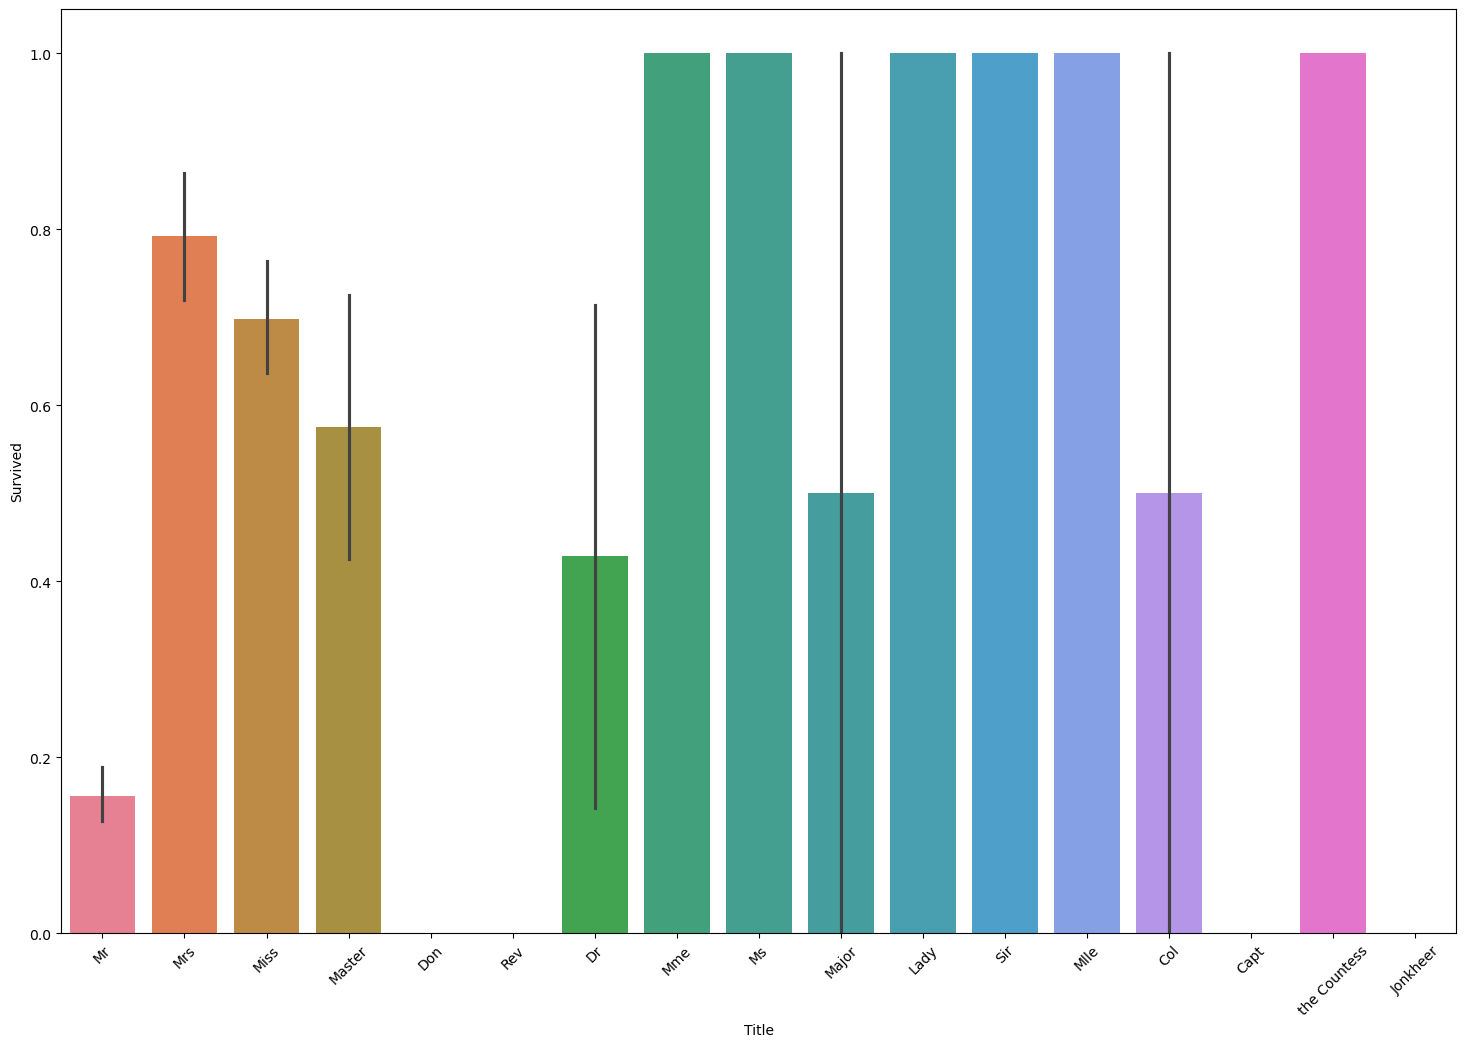

In [25]:
plt.figure(figsize=(18, 12))
g = sns.barplot(data=df_train_copy, x='Title', y='Survived',hue='Title')
g.set_xticklabels(labels=df_train_copy['Title'].unique(), rotation=45)
plt.show()

Observations

From the plot above there is a classification of title and their survival rate. Royal titles had a good survival rate. Common titles had a fair chance of survival and lowest level had the poorest chance in survival.

Classes for the titles will be:

[Master, Major, Lady, Sir, Col, the Countess] -> Royal(1)

[Mr, Mrs, Miss, Dr, Mme, Ms, Mlle] -> Common(2)

[Don, Rev, Capt, Jonkheer] -> Low(3)

This notebook will use label encoding.

In [26]:
def tilgrouping(X, attrib):
    royal = ['Master', 'Major', 'Lady', 'Sir', 'Col', 'the Countess']
    common = ['Mr', 'Mrs', 'Miss', 'Dr', 'Mme', 'Ms', 'Mlle']
    low = ['Don', 'Rev', 'Capt', 'Jonkheer']

    titleg = []

    for i in range(len(X[attrib])):
        if (X[attrib][i]) in royal:
            titleg.append(1)
        elif (X[attrib][i]) in common:
            titleg.append(2)
        elif (X[attrib][i]) in low:
            titleg.append(3)

    return titleg

df_train_copy ['TitleGroup'] = tilgrouping(df_train_copy , 'Title')
df_train_copy.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,AgeGroup,FareGroup,Title,TitleGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Youth,1,Mr,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Adult,2,Mrs,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Adult,1,Miss,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Adult,2,Mrs,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Adult,1,Mr,2


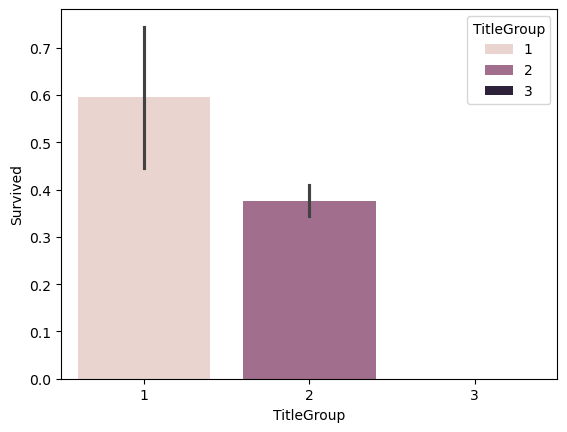

In [27]:
sns.barplot(data=df_train_copy, x='TitleGroup', y='Survived', hue='TitleGroup')
plt.show()

**Observations**

1. Class 1 which is royal has the higest chance at survival with:
2. class 3 with the lowest chance at survival

10. **Family Size and Family Type**

The Family Size and Family type are features engineered from _SibSp_ and _Parch_ features which singly have different effects on survival and this notebook wants to explore if they are combine what their effect is.

In [28]:
df_train_copy['FamilySize'] = df_train_copy['SibSp'] + df_train_copy['Parch']
df_train_copy.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,AgeGroup,FareGroup,Title,TitleGroup,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Youth,1,Mr,2,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Adult,2,Mrs,2,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Adult,1,Miss,2,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Adult,2,Mrs,2,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Adult,1,Mr,2,0


In [29]:
df_train_copy['FamilyType'] = pd.cut(df_train_copy['FamilySize'], bins=[-0.9, 1.1, 4, np.inf], labels=['Alone', 'Small', 'Big'])
df_train_copy.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,AgeGroup,FareGroup,Title,TitleGroup,FamilySize,FamilyType
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Youth,1,Mr,2,1,Alone
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Adult,2,Mrs,2,1,Alone


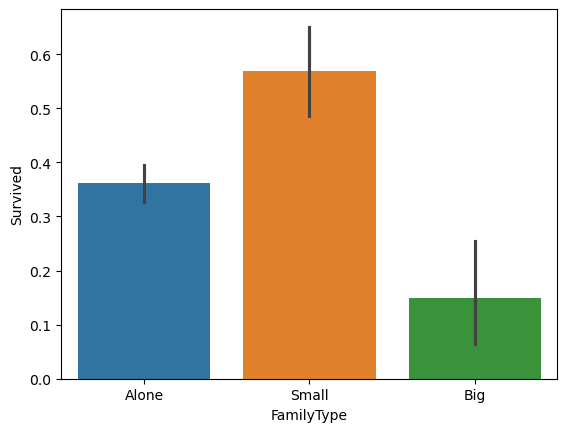

In [30]:
sns.barplot(data=df_train_copy, x='FamilyType', y ='Survived', hue='FamilyType')
plt.show()

#### Creating a Clean Train, Validation and Test Data

Before delving into modelling and any transformation, this notebook first identifies the necessary features. Then it splits the **train_data** into **train** and **validation** datasets. Lastly transformations required follow.

Required features: 'Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'AgeGroup', 'FareGroup', 'TitleGroup', 'FamilySize', 'FamilyType'

Features for Encoding: 'Sex', 'Embarked', 'AgeGroup', 'FamilyType'

###### **One-Hot Encoding**
1. Sex
2. Embarked
3. AgeGroup

###### **Label Encoding**
1. FamilyType

**Use one-hot encoding for nominal data (no order, e.g., colors). For ordinal data (has a rank, e.g., 'small', 'medium', 'large'), use label encoding.**

In [31]:
df_train_copy.drop(['Age', 'Embarked'], axis=1, inplace=True)
train_data = pd.concat([df_train_copy,Impute['Age'],data_impute['Embarked']] , axis=1)
train_data.head(2)


,PassengerId,Survived,Pclass,Name,Sex,SibSp,Parch,Ticket,Fare,Cabin,AgeGroup,FareGroup,Title,TitleGroup,FamilySize,FamilyType,Age,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,1,0,A/5 21171,7.2500,NaN,Youth,1,Mr,2,1,Alone,22.0,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,1,0,PC 17599,71.2833,C85,Adult,2,Mrs,2,1,Alone,38.0,C


In [32]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(train_data[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch',
                                                                 'Fare', 'Embarked', 'AgeGroup', 'FareGroup', 'TitleGroup', 'FamilySize', 'FamilyType']], train_data[['Survived']], test_size=0.3, random_state=42)

#### **One Hot Encoding**

In [33]:
dummies = pd.get_dummies(X_train[['Sex', 'Embarked', 'AgeGroup']], drop_first=True)
inputs = pd.concat([X_train.drop(['Sex', 'Embarked', 'AgeGroup'], axis=1), dummies], axis=1)

#### **Label Encoding**

In [34]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(inputs['FamilyType'])
inputs['FamilyType'] = le.fit_transform(inputs['FamilyType'])

inputs.head(2)

## final model data: input

,Pclass,Age,SibSp,Parch,Fare,FareGroup,TitleGroup,FamilySize,FamilyType,Sex_male,Embarked_Q,Embarked_S,AgeGroup_Child,AgeGroup_Youth,AgeGroup_Adult,AgeGroup_Senior
445,1,4.0,0,2,81.8583,2,1,2,2,True,False,True,False,False,False,False
650,3,NaN,0,0,7.8958,1,2,0,0,True,False,True,False,False,False,False


# *Modeling* #

In [35]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier


In [36]:
## show score for each cross validation #
def display_scores(scores):
    print('Scores: ', scores)
    print('Mean Score:', scores.mean())
    print('Std: ', scores.std())

## 1. Random Forest ##

In [37]:
rf_cls = RandomForestClassifier()

scores_rf = cross_val_score(rf_cls, inputs, y_train.values.ravel(), scoring='accuracy', cv=10)
display_scores(scores_rf)

##every cross validatoin accuracy score
#more of the scores
#std of the score

#.values.ravel() : make sure it is one dimension

Scores:  [0.77777778 0.80952381 0.85714286 0.80645161 0.80645161 0.67741935
 0.79032258 0.80645161 0.85483871 0.87096774]
Mean Score: 0.8057347670250895
Std:  0.051777603379898327


## 2. XG Boost ##

In [39]:
xgb_cls = XGBClassifier()

scores_xgb = cross_val_score(xgb_cls, inputs, y_train.values.ravel(), scoring='accuracy', cv=10)
display_scores(scores_xgb)

Scores:  [0.77777778 0.77777778 0.9047619  0.88709677 0.77419355 0.72580645
 0.82258065 0.79032258 0.82258065 0.87096774]
Mean Score: 0.8153865847414234
Std:  0.054315364920904836


#### Hyperparameter Tuning

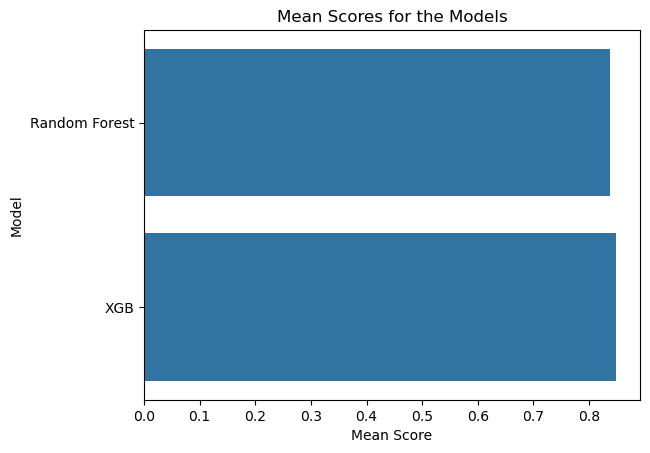

In [42]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold

# Random Forest param Grid
rf_param_grid = {
    'n_estimators': [100, 250, 400,],
    'criterion': ['gini', 'entropy'],
    "min_samples_split":[2,3,10],
    "min_samples_leaf":[1,3,10],
    'max_features': ['sqrt', 'log2'],
    'random_state':[8, 16, 42],
}


xgb_param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Classifiers
classifier_param = [rf_param_grid, xgb_param_grid]
classifier = [RandomForestClassifier(), XGBClassifier()]

cv_result = []
best_estimators = []

for i in range(len(classifier)):
    clf = GridSearchCV(classifier[i], param_grid=classifier_param[i],
                       scoring='accuracy', n_jobs=-1, cv=StratifiedKFold(n_splits=10))
    clf.fit(inputs, y_train.values.ravel())
    cv_result.append(clf.best_score_)
    best_estimators.append(clf.best_estimator_)

result = pd.DataFrame({'Mean Score': cv_result, 'Model': ['Random Forest', 'XGB']})

g = sns.barplot(data=result, x='Mean Score', y='Model')
g.set_xlabel('Mean Score')
g.set_title('Mean Scores for the Models')
plt.show()

In [45]:
print (f"best score for RF and XGB : {cv_result}")

best score for RF and XGB : [0.8377880184331797, 0.8491295442908345]


In [51]:
#save the best model

rf_model = best_estimators[0]
xgb_model= best_estimators[1]
best_estimators

[RandomForestClassifier(min_samples_leaf=10, n_estimators=250, random_state=42),
 XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=1.0, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric=None, feature_types=None,
               feature_weights=None, gamma=None, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=0.2, max_bin=None, max_cat_threshold=None,
               max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
               max_leaves=None, min_child_weight=None, missing=nan,
               monotone_constraints=None, multi_strategy=None, n_estimators=100,
               n_jobs=None, num_parallel_tree=None, ...)]

### use validation data set to validate the selected model performance ### 

In [47]:
# one hot coding
# dummy encoding
dummies_valid = pd.get_dummies(X_valid[['Sex', 'Embarked', 'AgeGroup']], drop_first=True)
inputs_valid = pd.concat([X_valid.drop(['Sex', 'Embarked', 'AgeGroup'], axis=1), dummies_valid], axis=1)
#label encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(inputs_valid['FamilyType'])
inputs_valid['FamilyType'] = le.transform(inputs_valid['FamilyType'])

inputs_valid.head()

,Pclass,Age,SibSp,Parch,Fare,FareGroup,TitleGroup,FamilySize,FamilyType,Sex_male,Embarked_Q,Embarked_S,AgeGroup_Child,AgeGroup_Youth,AgeGroup_Adult,AgeGroup_Senior
709,3,NaN,1,1,15.2458,1,1,2,2,True,False,False,False,False,False,False
439,2,31.0,0,0,10.5000,1,2,0,0,True,False,True,False,False,True,False
840,3,20.0,0,0,7.9250,1,2,0,0,True,False,True,False,True,False,False
720,2,6.0,0,1,33.0000,1,2,1,0,False,False,True,False,False,False,False
39,3,14.0,1,0,11.2417,1,2,1,0,False,False,False,True,False,False,False


In [49]:
rf_preds = rf_model.predict(inputs_valid)
xgb_preds = xgb_model.predict(inputs_valid)


rf_acc = accuracy_score(y_valid.values.ravel(), rf_preds)
xgb_acc = accuracy_score(y_valid.values.ravel(), xgb_preds)


print(f'Accuracies -> Random Forest: {rf_acc}, XBM: {xgb_acc}')

Accuracies -> Random Forest: 0.8171641791044776, XBM: 0.832089552238806


# Predict Survival of the Passengers in the Test Data #

In [52]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [80]:
# data used in imputing
data_impute_test = df_test[['Pclass', 'Sex','Age', 'SibSp','Parch', 'Fare', 'Embarked']]
#data_impute_test.head()

# Sex and Embarked Encoding
Impute_dummy_test = pd.get_dummies(data_impute_test[['Sex', 'Embarked']], drop_first=True)
Impute_test = pd.concat([data_impute_test.drop(['Sex', 'Embarked'], axis=1), Impute_dummy_test], axis=1)

# Scaling : use train data set trained scalar -- scaler;
X_test_scalar = scaler.transform(Impute_test)
data_test_scalar = pd.DataFrame(data=X_test_scalar, columns=Impute_test.columns)

# Imputing Missing Values
X_test_KNN = knn_imputer.transform(data_test_scalar)
data_test_KNN_scalar = pd.DataFrame(data=X_test_KNN, columns=Impute_test.columns)

Xinv_test = scaler.inverse_transform(data_test_KNN_scalar)
data_test_KNN = pd.DataFrame(data=Xinv_test, columns=Impute_test.columns)


data_test_age = data_test_KNN

data_test_KNN.head()


,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3.0,34.5,0.0,0.0,7.8292,1.0,1.0,0.0
1,3.0,47.0,1.0,0.0,7.0000,0.0,0.0,1.0
2,2.0,62.0,0.0,0.0,9.6875,1.0,1.0,0.0
3,3.0,27.0,0.0,0.0,8.6625,1.0,0.0,1.0
4,3.0,22.0,1.0,1.0,12.2875,0.0,0.0,1.0


In [89]:
print(inputs.columns)
print(df_test.columns)

Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FareGroup', 'TitleGroup',
       'FamilySize', 'FamilyType', 'Sex_male', 'Embarked_Q', 'Embarked_S',
       'AgeGroup_Child', 'AgeGroup_Youth', 'AgeGroup_Adult',
       'AgeGroup_Senior'],
      dtype='object')
Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [157]:
df_test_copy = df_test.copy()
df_test_copy.drop(['Age'], axis=1, inplace=True)

##Age;
df_test_copy = pd.concat([df_test_copy,data_test_age[['Age']]] , axis=1)
df_test_copy['AgeGroup'] = pd.cut(df_test_copy['Age'], bins = [0, 6, 16 , 22, 50, np.inf], labels = labels)

## sex, Embarked, agegroup;
dummies_test = pd.get_dummies(df_test_copy[['Sex', 'Embarked', 'AgeGroup']], drop_first=True)
df_test_copy = pd.concat([df_test_copy.drop(['Sex', 'Embarked', 'AgeGroup'], axis=1), dummies_test], axis=1)


##Fare;
df_test_copy['Fare'][(df_test_copy['Pclass'] == 1) & (df_test_copy['Fare'] == 0)] = pclass_mean1
df_test_copy['Fare'][(df_test_copy['Pclass'] == 2) & (df_test_copy['Fare'] == 0)] = pclass_mean2
df_test_copy['Fare'][(df_test_copy['Pclass'] == 3) & (df_test_copy['Fare'] == 0)] = pclass_mean3
df_test_copy['Fare'][(df_test_copy['Pclass'] == 3) & (df_test_copy['Fare'].isnull())] = pclass_mean3

df_test_copy['FareGroup'] = pd.cut(df_test_copy['Fare'], bins = [0, 41, 101, 201, np.inf], labels=[1, 2, 3, 4]).astype(int)

df_test_copy['Title'] = titling(df_test_copy, 'Name')
df_test_copy ['TitleGroup'] = tilgrouping(df_test_copy , 'Title')
df_test_copy.drop(['Title','Name'], axis=1, inplace=True)

df_test_copy['FamilySize'] = df_train_copy['SibSp'] + df_train_copy['Parch']
df_test_copy['FamilyType'] = pd.cut(df_test_copy['FamilySize'], bins=[-0.9, 1.1, 4, np.inf], labels=['Alone', 'Small', 'Big'])

#label encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(df_test_copy['FamilyType'])
df_test_copy['FamilyType'] = le.transform(df_test_copy['FamilyType'])

#drop all variables will not be used in modeling
df_test_copy.drop(['Ticket','Cabin','PassengerId'], axis=1, inplace=True)

inputs_test = df_test_copy

/var/folders/3d/c20qd2t57zvbpp10zzxyxz1r0000gn/T/ipykernel_88700/1619066473.py:14: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_test_copy['Fare'][(df_test_copy['Pclass'] == 1) & (df_test_copy['Fare'] == 0)] = pclass_mean1
/var/folders/3d

In [158]:
print(inputs_test.info())
print(inputs.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Pclass           418 non-null    int64  
 1   SibSp            418 non-null    int64  
 2   Parch            418 non-null    int64  
 3   Fare             418 non-null    float64
 4   Age              418 non-null    float64
 5   Sex_male         418 non-null    bool   
 6   Embarked_Q       418 non-null    bool   
 7   Embarked_S       418 non-null    bool   
 8   AgeGroup_Child   418 non-null    bool   
 9   AgeGroup_Youth   418 non-null    bool   
 10  AgeGroup_Adult   418 non-null    bool   
 11  AgeGroup_Senior  418 non-null    bool   
 12  FareGroup        418 non-null    int64  
 13  TitleGroup       418 non-null    int64  
 14  FamilySize       418 non-null    int64  
 15  FamilyType       418 non-null    int64  
dtypes: bool(7), float64(2), int64(7)
memory usage: 32.4 KB
None
<c

In [133]:
print(inputs_test.info())
print(inputs.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   PassengerId      418 non-null    int64   
 1   Pclass           418 non-null    int64   
 2   SibSp            418 non-null    int64   
 3   Parch            418 non-null    int64   
 4   Ticket           418 non-null    object  
 5   Fare             417 non-null    float64 
 6   Cabin            91 non-null     object  
 7   Age              418 non-null    float64 
 8   Sex_male         418 non-null    bool    
 9   Embarked_Q       418 non-null    bool    
 10  Embarked_S       418 non-null    bool    
 11  AgeGroup_Child   418 non-null    bool    
 12  AgeGroup_Youth   418 non-null    bool    
 13  AgeGroup_Adult   418 non-null    bool    
 14  AgeGroup_Senior  418 non-null    bool    
 15  FareGroup        417 non-null    category
 16  TitleGroup       418 non-null    int64   
 1

In [167]:
#save processed test data
inputs_test.to_csv('./Titanic_test_processed.csv',index=False)

outputs_test = xgb_model.predict(inputs_test[['Pclass',  'Age', 'SibSp', 'Parch', 'Fare','FareGroup','TitleGroup','FamilySize', 'FamilyType',
                                              'Sex_male',	'Embarked_Q',	'Embarked_S',	'AgeGroup_Child',
                                              'AgeGroup_Youth',	'AgeGroup_Adult',	'AgeGroup_Senior'  ]])

outputs_test_pred = pd.concat([df_test['PassengerId'], pd.Series(outputs_test, name='Survived')], axis=1)
outputs_test_pred.to_csv('survived_submission.csv', index=False)

In [166]:
outputs_test_pred

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


### **Saving the Model(s)**

In [168]:
import joblib
import os

path = './'
filenames =  ['Titanic_RF_model.joblib','Titanic_XGB_model.joblib']
models = [ rf_model, xgb_model]

for i in range(len(filenames)):
  joblib.dump(models[i], os.path.join(path, filenames[i]))